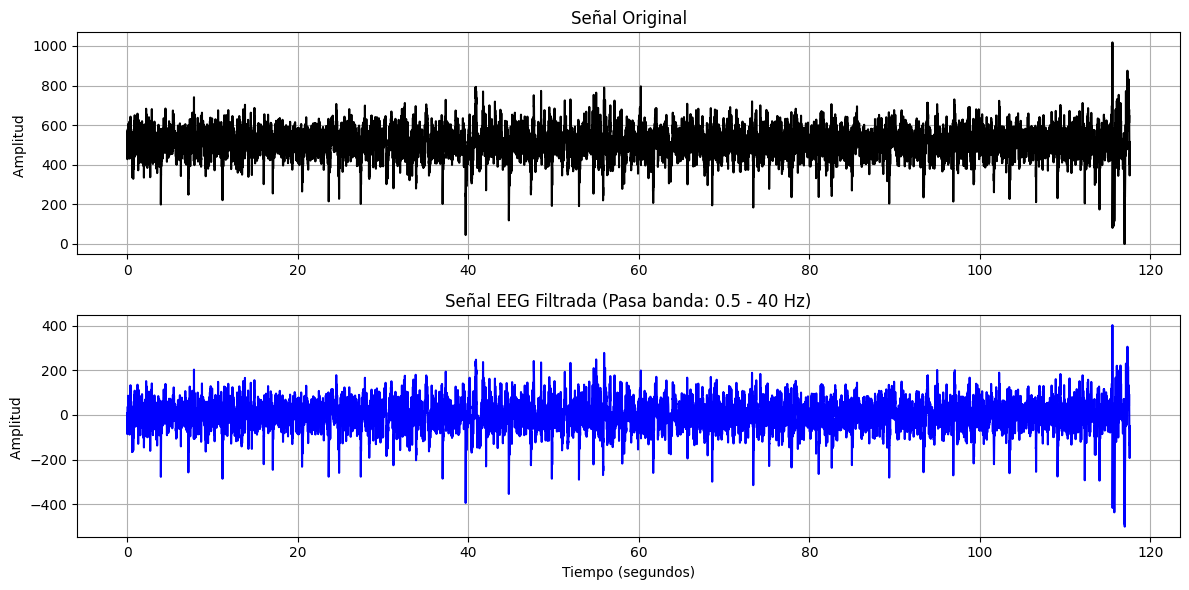

In [ ]:
import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# Lectura de archivos
datos = np.loadtxt("matias-L1.txt", comments="#")

# Seleccion de canales
eeg_crudo = datos[:, 5]

# Parametros de la señal
fs = 1000
N = len(eeg_crudo)
t = np.arange(N) / fs

# Filtrados la señal (filtro DC)
eeg_centrado = eeg_crudo - np.mean(eeg_crudo)

# Filtro pasa banda (0.5 Hz - 40 Hz)
lowcut = 0.5
highcut = 40.0
nyq = 0.5 * fs

low = lowcut / nyq
high = highcut / nyq

# Creamos el filtro Butterworth de orden 4
b, a = butter(4, [low, high], btype='band')

# Aplicamos el filtro a la señal centrada
eeg_filtrado = filtfilt(b, a, eeg_centrado)

# Ploteamos la señal
plt.figure(figsize=(12, 6))

# Gráfica de la señal original
plt.subplot(2, 1, 1)
plt.plot(t, eeg_crudo, color='black')
plt.title("Señal Original")
plt.ylabel("Amplitud ")
plt.grid()

# Gráfica de la señal filtrada
plt.subplot(2, 1, 2)
plt.plot(t, eeg_filtrado, color='blue')
plt.title("Señal EEG Filtrada (Pasa banda: 0.5 - 40 Hz)")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud ")
plt.grid()

plt.tight_layout()
plt.show()